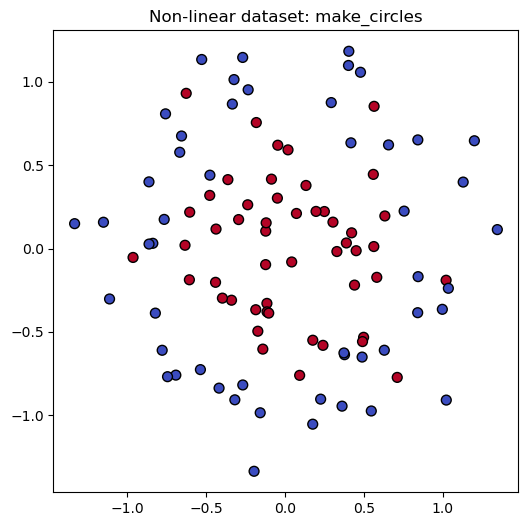

Shape of dataset: (100, 2)
Unique classes: [0 1]


In [1]:
# =====================================
# Task 1: Load and Explore the Dataset
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles, make_moons

# Create dataset (non-linear, circular pattern)
X, y = make_circles(noise=0.2, factor=0.5, random_state=42)

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=50, edgecolors='k')
plt.title("Non-linear dataset: make_circles")
plt.show()

print("Shape of dataset:", X.shape)
print("Unique classes:", np.unique(y))


In [2]:
# =====================================
# Task 2: Data Preprocessing
# =====================================
from sklearn.preprocessing import StandardScaler

# Scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# No missing values check
print("Missing values:", pd.DataFrame(X).isnull().sum().sum())


Missing values: 0


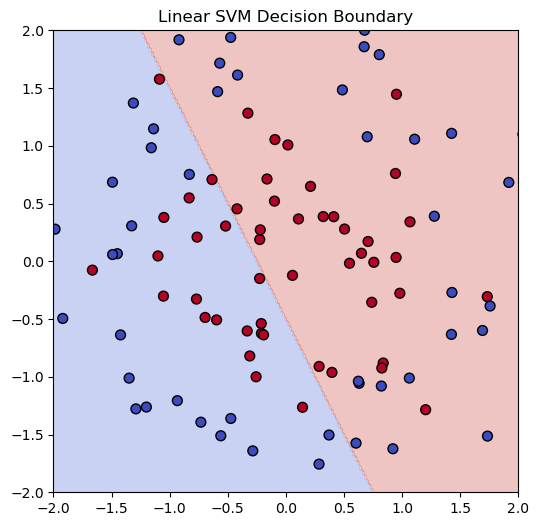

In [3]:
# =====================================
# Task 3: Train Linear SVM as Baseline
# =====================================
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_scaled, y)

# Function to plot decision boundary
def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(6,6))
    ax = plt.gca()
    xlim = ax.set_xlim(-2, 2)
    ylim = ax.set_ylim(-2, 2)

    # Create grid
    xx, yy = np.meshgrid(np.linspace(-2, 2, 200),
                         np.linspace(-2, 2, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=50, edgecolors="k")
    plt.title(title)
    plt.show()

plot_decision_boundary(linear_svm, X_scaled, y, "Linear SVM Decision Boundary")


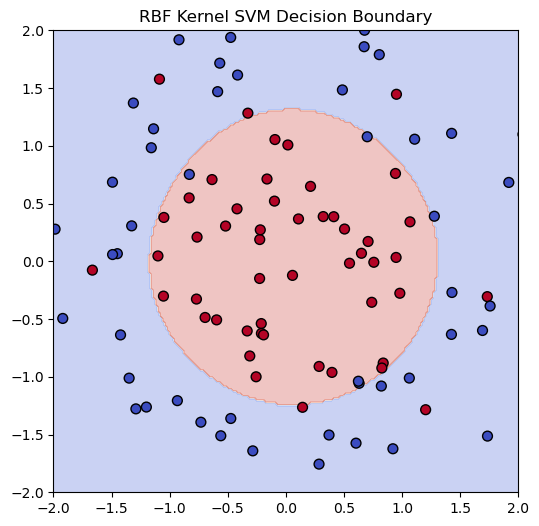

In [4]:
# =====================================
# Task 4: Train Non-Linear SVM with RBF Kernel
# =====================================
rbf_svm = SVC(kernel='rbf', random_state=42)
rbf_svm.fit(X_scaled, y)

plot_decision_boundary(rbf_svm, X_scaled, y, "RBF Kernel SVM Decision Boundary")


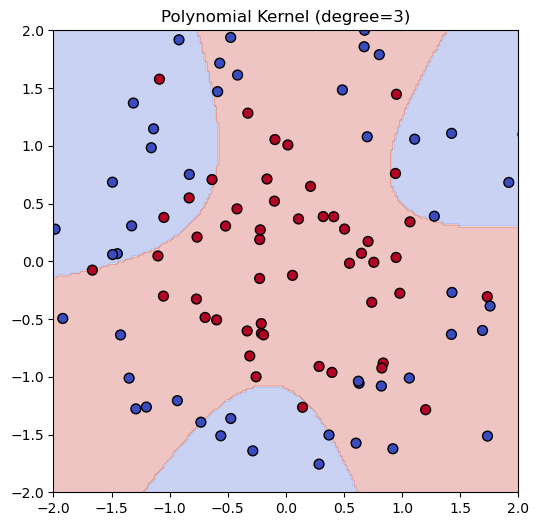

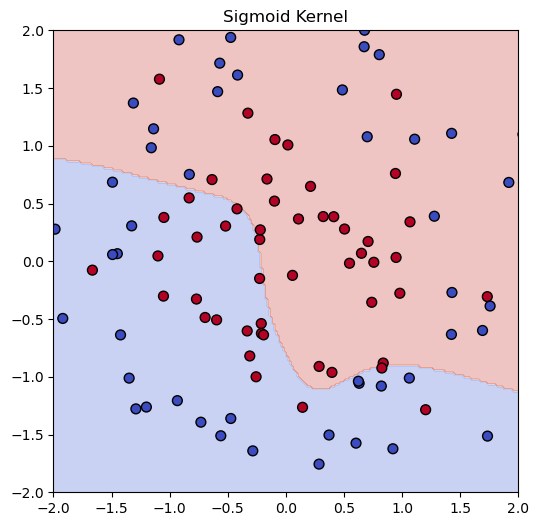

In [5]:
# =====================================
# Task 5: Experiment with Other Kernels
# =====================================
poly_svm = SVC(kernel='poly', degree=3, random_state=42)
poly_svm.fit(X_scaled, y)

sigmoid_svm = SVC(kernel='sigmoid', random_state=42)
sigmoid_svm.fit(X_scaled, y)

plot_decision_boundary(poly_svm, X_scaled, y, "Polynomial Kernel (degree=3)")
plot_decision_boundary(sigmoid_svm, X_scaled, y, "Sigmoid Kernel")


In [6]:
# =====================================
# Task 6: Hyperparameter Tuning
# =====================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 1, 0.5, 0.1, 0.01],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'degree': [2, 3, 4]  # only matters for poly
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_scaled, y)

print("Best Parameters:", grid.best_params_)
print("Best Cross-validation Accuracy:", grid.best_score_)


Best Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-validation Accuracy: 0.89


Test Accuracy: 0.7333333333333333

Confusion Matrix:
 [[13  2]
 [ 6  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.87      0.76        15
           1       0.82      0.60      0.69        15

    accuracy                           0.73        30
   macro avg       0.75      0.73      0.73        30
weighted avg       0.75      0.73      0.73        30



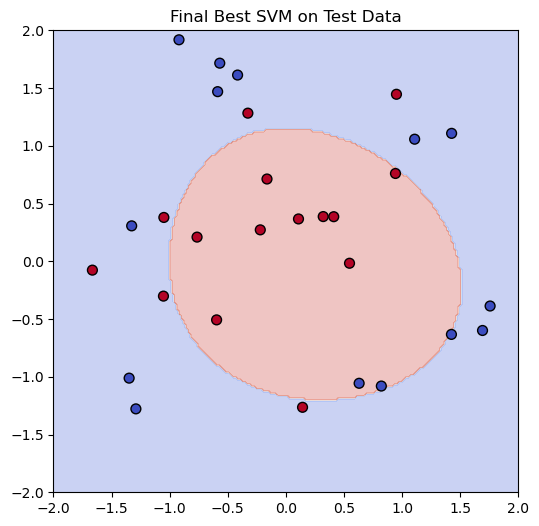

In [7]:
# =====================================
# Task 7: Evaluate Model Performance
# =====================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Train best model
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

# Predict
y_pred = best_model.predict(X_test)

# Evaluation
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Final decision boundary
plot_decision_boundary(best_model, X_test, y_test, "Final Best SVM on Test Data")


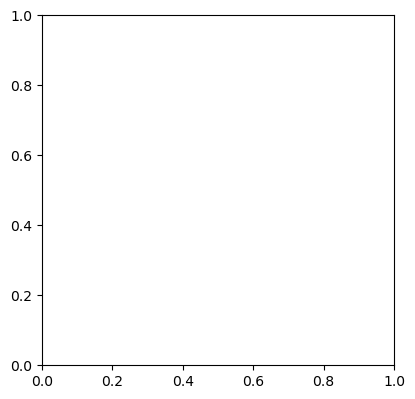

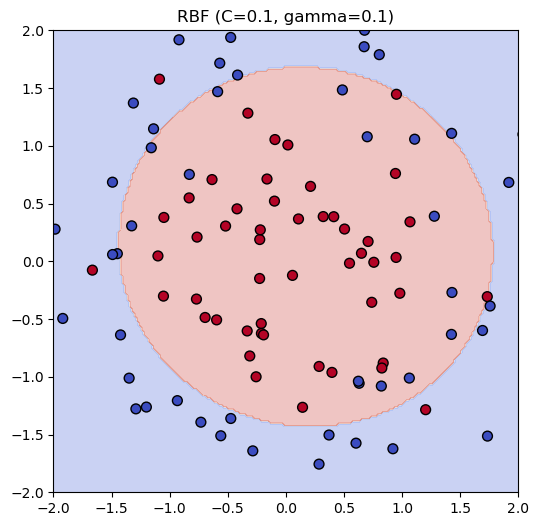

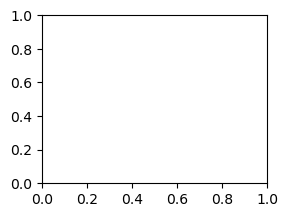

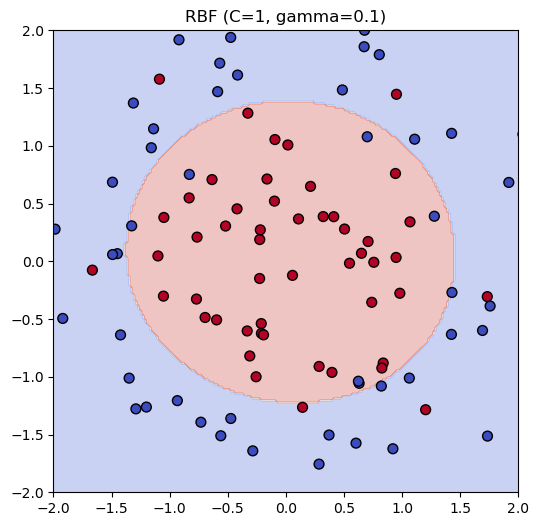

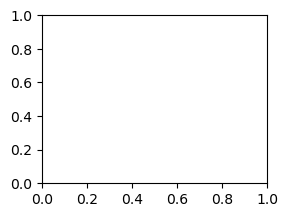

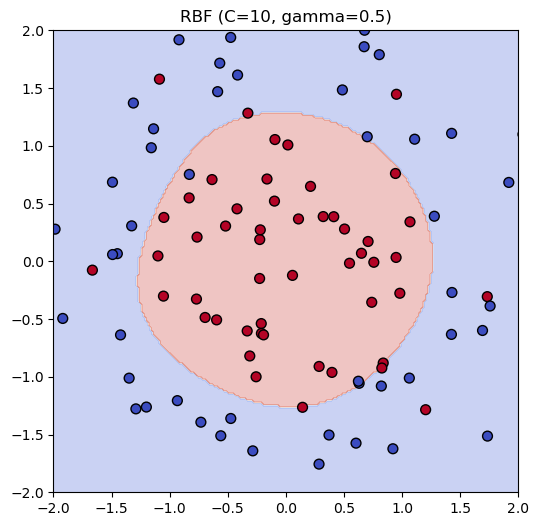

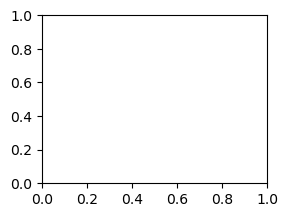

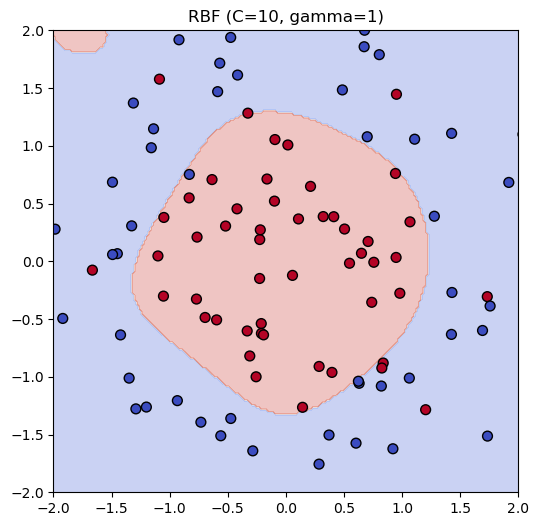

In [10]:
params = [(0.1, 0.1), (1, 0.1), (10, 0.5), (10, 1)]
plt.figure(figsize=(10,10))

for i, (C, gamma) in enumerate(params, 1):
    rbf_model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
    rbf_model.fit(X_scaled, y)
    
    plt.subplot(2,2,i)
    plot_decision_boundary(rbf_model, X_scaled, y, f"RBF (C={C}, gamma={gamma})")


In [11]:
from sklearn.model_selection import cross_val_score

best_rbf = SVC(kernel='rbf', C=10, gamma=0.5, random_state=42)
scores = cross_val_score(best_rbf, X_scaled, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean CV Accuracy:", scores.mean())


Cross-validation scores: [0.85 0.75 0.9  0.8  0.9 ]
Mean CV Accuracy: 0.8400000000000001
